# 00-03：坐标、方向与 360 数据质量

**适合读者：** 已完成 00-02、理解一行 event 含义的学习者。

**前置知识：** event UUID、结构性缺失、数据事实与指标结果。

**完成后能够：** 用可复用接口关联单场 events 与 360，解释坐标方向、可见区域和缺失边界，并判断场景表是否可以进入后续分析。

## 学习路线

1. 锁定数据和坐标契约。
2. 加载单场 events + 360。
3. 检查 ID 关联、坐标、visible area 和 freeze-frame 标记。
4. 建立一行一个 360 frame 的可拼接场景表。
5. 用射门位置检查统一进攻方向。
6. 练习将同一管道迁移到多场比赛。

In [1]:
from __future__ import annotations

import subprocess

import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch

from football_analytics import (
    assert_spatial_quality,
    build_360_event_rows,
    build_spatial_quality_report,
    get_open_data_root,
    load_match_spatial_data,
    summarize_shot_direction,
)

MATCH_ID = 3773585
EXPECTED_SOURCE_COMMIT = "b0bc9f22dd77c206ddedc1d742893b3bbe64baec"
OPEN_DATA_ROOT = get_open_data_root()
source_commit = subprocess.check_output(
    ["git", "-C", str(OPEN_DATA_ROOT), "rev-parse", "HEAD"], text=True
).strip()
assert source_commit == EXPECTED_SOURCE_COMMIT
source_commit

'b0bc9f22dd77c206ddedc1d742893b3bbe64baec'

## 1. 先明确本课不回答什么

“压力—选择—结果”只是应用背景。本课不规定高压距离、短传阈值或 build-up 成败，只检查未来计算这些变量所依赖的数据是否可靠。

StatsBomb 的 event 和 360 使用 `120 x 80` 球场坐标，并已经把控球队表示成从左向右、朝 `x=120` 进攻。因此不能因为真实比赛换边而再次翻转第二半场。

In [2]:
match = load_match_spatial_data(MATCH_ID)
report = build_spatial_quality_report(match)

overview = pd.DataFrame(
    {
        "events": [report["event_count"]],
        "360 frames": [report["frame_count"]],
        "matched frames": [report["matched_frame_count"]],
        "events without 360": [report["events_without_360_count"]],
        "360 coverage": [report["frame_coverage_rate"]],
    },
    index=[MATCH_ID],
)
overview.style.format({"360 coverage": "{:.1%}"})

,events,360 frames,matched frames,events without 360,360 coverage
3773585,4213,3858,3858,355,91.6%


**读法：** event 是全场事件母集，360 frame 是其中有冻结画面的子集。`events without 360` 是覆盖边界，不应自动标成数据错误。真正危险的是某个 frame 的 UUID 无法指向 event，或者同一 UUID 重复出现。

In [3]:
identifier_checks = pd.Series(report["identifiers"], name="count").to_frame()
identifier_checks.loc["unmatched_frame_count"] = report["unmatched_frame_count"]
identifier_checks

,count
missing_event_id_count,0
duplicate_event_id_count,0
missing_frame_uuid_count,0
duplicate_frame_uuid_count,0
unmatched_frame_count,0


## 2. 坐标检查必须按数据来源解释

event 起点、事件终点和 visible-area 多边形顶点应该位于球场范围内。freeze-frame 球员则可能合法地站在边线外，例如准备掷界外球或处于摄像机估计范围边缘。因此我们报告线外人数，但不会强制删除。

In [4]:
coordinate_sections = [
    "event_locations",
    "event_end_locations",
    "freeze_frame_locations",
    "visible_area_vertices",
]
coordinate_checks = pd.DataFrame({name: report[name] for name in coordinate_sections}).T
coordinate_checks

,count,malformed_count,outside_pitch_count
event_locations,4186,0,0
event_end_locations,2226,0,0
freeze_frame_locations,65283,0,377
visible_area_vertices,22457,0,0


In [5]:
container_checks = (
    pd.concat(
        {
            "freeze_frames": pd.Series(report["freeze_frames"]),
            "visible_areas": pd.Series(report["visible_areas"]),
        },
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
container_checks

,freeze_frames,visible_areas
malformed_count,0,0
malformed_player_count,0,0
malformed_player_flag_count,0,0
empty_count,0,0
without_visible_actor_count,0,0
multiple_visible_actors_count,0,0
missing_count,0,0


`without_visible_actor_count` 也需要单独解释：actor 可能在画面外，它与 frame 无法关联或坐标畸形不是同一种问题。质量断言只阻止会让关联或计算不可靠的问题。

In [6]:
assert_spatial_quality(report)
"关键空间质量检查通过"

'关键空间质量检查通过'

## 3. 建立可复用场景表

`build_360_event_rows` 用稳定 UUID 关联数据，一行代表一个 360 frame。表中保留 `match_id`，所以未来可以安全拼接不同比赛，而不需要复制 Notebook。

In [7]:
scene_rows = build_360_event_rows(match)
scenes = pd.DataFrame(scene_rows)
scene_columns = [
    "match_id",
    "event_uuid",
    "period",
    "minute",
    "event_type",
    "team_name",
    "visible_player_count",
    "visible_teammate_count",
    "visible_opponent_count",
]
display(scenes[scene_columns].head())
print(f"场景表：{len(scenes):,} 行，event_uuid 唯一={scenes['event_uuid'].is_unique}")

,match_id,event_uuid,period,minute,event_type,team_name,visible_player_count,visible_teammate_count,visible_opponent_count
0,3773585,af0b092d-5878-4fc8-9a12-60641e06e816,1,0,Pass,Real Madrid,20,10,10
1,3773585,da416422-e4af-40bb-be13-a9817ea5197b,1,0,Ball Receipt*,Real Madrid,20,10,10
2,3773585,9ce58572-14c0-4cfb-b8d0-26e2422b5314,1,0,Pass,Real Madrid,20,10,10
3,3773585,a3f0e900-7627-4ef0-9133-c6da8506e43c,1,0,Ball Receipt*,Real Madrid,20,10,10
4,3773585,e610c17c-e75b-4bd2-9f93-0c67686eebef,1,0,Pass,Real Madrid,20,10,10


场景表：3,858 行，event_uuid 唯一=True


这张表还不是门将 build-up 表。它只是经过检查的 event–360 基础层；压力、选择和后续结果需要在后续 lesson 中另行定义。

## 4. 用射门位置检查进攻方向

按球队和半场分别看射门起点。如果第二半场仍主要靠近 `x=120` 一侧，就能直观看到供应商已经统一了进攻方向。这个检查只验证表示方式，不评价射门质量。

In [8]:
direction = pd.DataFrame(summarize_shot_direction(match.events))
direction

,team_id,team_name,period,shot_count,median_start_x,attacking_half_count
0,217,Barcelona,1,5,97.50,5
1,217,Barcelona,2,5,108.80,5
2,220,Real Madrid,1,6,108.75,6
3,220,Real Madrid,2,10,106.55,10


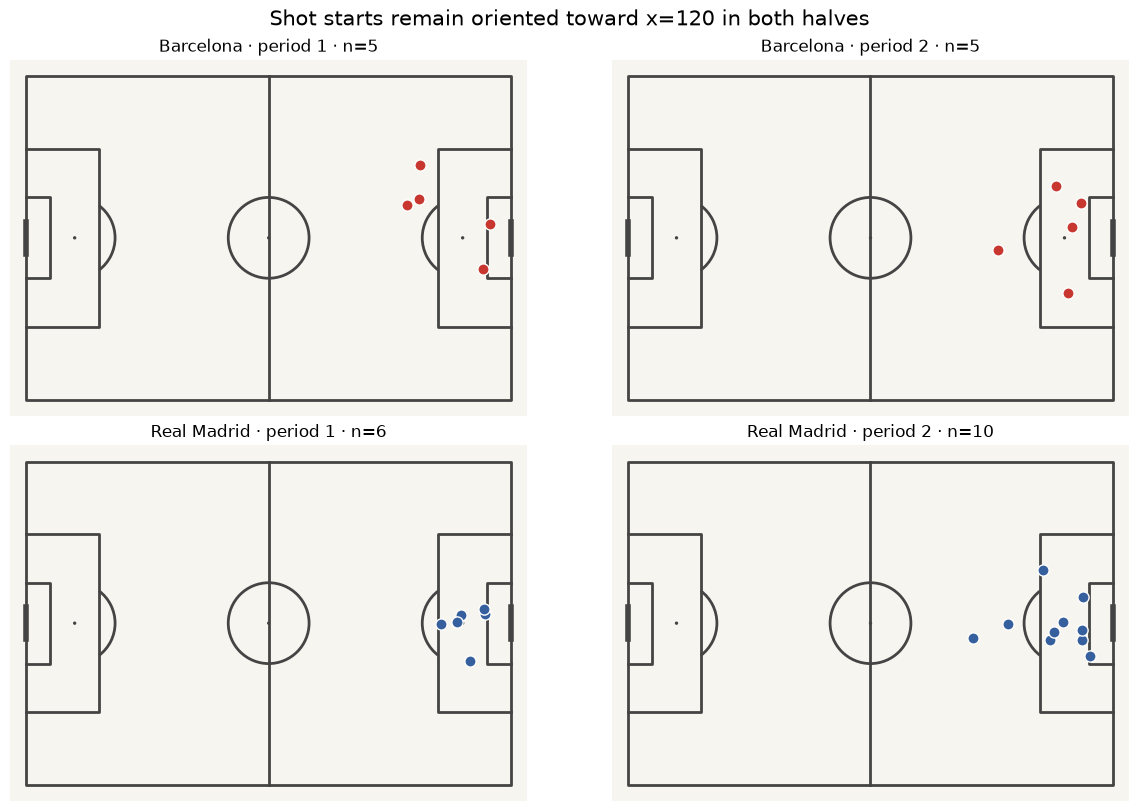

In [9]:
team_order = ["Barcelona", "Real Madrid"]
period_order = [1, 2]
pitch = Pitch(pitch_type="statsbomb", pitch_color="#f7f5ef", line_color="#444444")
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for row_index, team_name in enumerate(team_order):
    for column_index, period in enumerate(period_order):
        ax = axes[row_index, column_index]
        pitch.draw(ax=ax)
        shots = [
            event
            for event in match.events
            if event.get("type", {}).get("name") == "Shot"
            and event.get("team", {}).get("name") == team_name
            and event.get("period") == period
            and event.get("location")
        ]
        pitch.scatter(
            [event["location"][0] for event in shots],
            [event["location"][1] for event in shots],
            s=65,
            color="#c7362f" if team_name == "Barcelona" else "#365f9d",
            edgecolors="white",
            ax=ax,
        )
        ax.set_title(f"{team_name} · period {period} · n={len(shots)}")

fig.suptitle("Shot starts remain oriented toward x=120 in both halves", fontsize=15)
plt.show()

**常见错误：** 按电视画面或上下半场再次翻转坐标。这会让同一球队两半场的进攻方向相反，并破坏跨比赛比较。

**本图不能证明：** 球队为何在这些位置射门、哪一方进攻更好，或者某种压力造成了什么选择。

## 练习：把单场接口迁移为批量调用

先预测：换一场有 360 的比赛后，覆盖率和线外 freeze-frame 球员比例会更高还是更低？然后只更换 `match_ids`，不要修改质量规则。下面的答案脚手架先用当前比赛验证批量模式。

In [10]:
def prepare_360_matches(match_ids: list[int]) -> tuple[pd.DataFrame, pd.DataFrame]:
    tables = []
    reports = []
    for match_id in match_ids:
        current_match = load_match_spatial_data(match_id)
        current_report = build_spatial_quality_report(current_match)
        assert_spatial_quality(current_report)
        tables.append(pd.DataFrame(build_360_event_rows(current_match)))
        reports.append(current_report)
    return pd.concat(tables, ignore_index=True), pd.DataFrame(reports)


practice_scenes, practice_reports = prepare_360_matches([MATCH_ID])
practice_reports[["match_id", "event_count", "frame_count", "frame_coverage_rate"]]

,match_id,event_count,frame_count,frame_coverage_rate
0,3773585,4213,3858,0.915737


## 结论与下一步

本课回答的是“数据能否可靠进入测量”，而不是“压力如何影响门将决策”。下一步可以在这张经过验证的基础场景表上定义门将出球 episode；探索集和验证集只替换比赛 ID，继续复用相同加载、关联和质量检查。